# Predicting Customer Churn rate using - MLP (Binary classification)

In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [14]:
# =======================================================
# MODULE 1: IMPORTING DATA & PERFORMING CROSS VALIDATION 
# =======================================================

df = pd.read_csv("../data/Churn_Modelling.csv")

In [15]:
# Getting to know about the data
print(f"Shape of the dataset : {df.shape}")
df.head()

Shape of the dataset : (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
# Checking the datatypes 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [17]:
# checking Is there any duplicate values in data set
df.duplicated().sum()

0

In [18]:
# Number of customer exited from bank 1-->exit
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [19]:
# Number of customers from different counties
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [20]:
# Number of Bank's active members 1-> active 
df['IsActiveMember'].value_counts() 

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [21]:
# Dropping the least important columns 
df.drop(columns=['RowNumber', 'CustomerId',	'Surname'], inplace=True) # for permanent change


In [22]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
# Performing one-hot encoding for Geography and gender as model can only be trained on numbers 
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [24]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [26]:
# =========================================
# MODULE 2: DATA SPLITTING & NORMALIZATION  
# =========================================

from sklearn.model_selection import train_test_split

# Feature matrix
X = df.drop(columns=['Exited'])

# Target vector 
y = df['Exited']

# Splitting the data into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of y_train : {y_train.shape}")

Shape of X_train : (8000, 11)
Shape of y_train : (8000,)


In [27]:
# NORMALIZATION : To avoid over shotting and slow convergence of weights 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scaling training and test feature matrices 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [28]:
# =========================================
# MODULE 3: MULTI-LAYERED PERCEPTRON (MLP) 
# =========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Initializing the Model  
model = Sequential()

# Hidden layer 0(Input layer)
model.add(Dense(11, activation='relu', input_dim=11))

# Hidden layer 1
model.add(Dense(7, activation='relu'))

# Hidden layer 2
model.add(Dense(1, activation='sigmoid'))


/Users/arbazkhan/kael/kael_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Summary of Trainable Parameters 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compiling the Model
model.compile(loss = 'binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [31]:
# Model Training 
hist = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2 )


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.5522 - loss: 0.7363 - val_accuracy: 0.8100 - val_loss: 0.5139
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - accuracy: 0.7942 - loss: 0.4914 - val_accuracy: 0.8144 - val_loss: 0.4484
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.8006 - loss: 0.4568 - val_accuracy: 0.8219 - val_loss: 0.4262
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - accuracy: 0.8025 - loss: 0.4411 - val_accuracy: 0.8263 - val_loss: 0.4139
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - accuracy: 0.8084 - loss: 0.4301 - val_accuracy: 0.8300 - val_loss: 0.4026
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step - accuracy: 0.8169 - loss: 0.4193 - val_accuracy: 0.8331 - val_loss: 0.3920
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - accuracy: 0.8275 - loss: 0.4076 - val_accuracy: 0.8381 - val_loss: 0.3804
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step - accuracy: 0.8372 - loss: 0

In [ ]:
# Weights and biases of Hidden layer 0
model.layers[0].get_weights()

[array([[-0.03173172, -0.3892046 ,  0.04587913, -0.3446353 , -0.08259137,
          0.04368181,  0.16984619,  0.43907768,  0.10973375, -0.22103581,
         -0.0225723 ],
        [ 0.02386387,  0.6653632 , -0.64497983,  0.28789026,  0.9765244 ,
         -0.7279477 ,  0.02357693,  0.10500114,  0.4346967 ,  0.10320628,
          0.18680386],
        [-0.20309426, -0.01358946, -0.3482996 , -0.06769753, -0.0269279 ,
         -0.07783262, -0.26643103, -0.35018358, -0.27056333,  0.3135094 ,
          0.4711939 ],
        [-0.34984434,  0.03780684,  0.06797517,  0.03851774, -0.05726501,
          0.15256153,  0.53109664, -0.10078383, -0.47658765, -0.64067274,
         -0.4833286 ],
        [ 0.14439224, -0.11447711,  0.22068314, -0.6331627 ,  1.1256533 ,
          0.003857  ,  0.7634111 , -0.06487315, -0.96744734,  1.318873  ,
          0.2071216 ],
        [-0.52649975, -0.35655564, -0.03134248,  0.05094812,  0.01847392,
          0.10115673,  0.04937142,  0.18668795, -0.0236711 ,  0.3103682

In [ ]:
# Weights and biases of hidden layer 1
model.layers[1].get_weights()

[array([[-0.9192548 , -0.44368973,  0.44137892, -0.23872644,  0.234992  ,
          0.20248751,  0.21350522],
        [ 1.1824886 ,  0.4707731 , -0.27752104, -0.5532779 ,  0.26231083,
         -0.26869932, -0.13676801],
        [ 0.01453905, -0.10980913,  0.22026965, -0.5597395 , -0.66805506,
         -0.45087686,  0.40691757],
        [-0.6114045 ,  0.293157  ,  0.11610642,  0.7134026 ,  0.03299116,
         -0.21910879,  0.14622849],
        [ 0.8894892 , -0.09180069, -0.07447438,  0.3424896 , -1.1709238 ,
          0.7829494 ,  0.549792  ],
        [ 0.26268446,  0.32004452,  0.41264808, -0.49856403, -0.59046364,
         -0.38909888, -0.02439044],
        [ 0.11698852,  0.08022482, -0.5400792 ,  0.36289608, -0.40414935,
          0.69937485, -0.50791484],
        [ 0.13937302, -0.31846955,  0.4847903 ,  0.22079974,  0.11776473,
         -0.13705057,  0.19379678],
        [ 0.11358476,  0.77196693, -0.55803055, -0.14631005,  0.6110589 ,
         -0.57010734, -0.38469988],
        [-

In [ ]:
# Weights and biases of hidden layer 2
model.layers[2].get_weights()

[array([[-1.1054804],
        [ 0.510141 ],
        [-0.9214713],
        [ 1.2316004],
        [ 1.3639729],
        [ 1.2882897],
        [-0.6992543]], dtype=float32),
 array([-0.33018646], dtype=float32)]

In [39]:
# ============================
# MODULE 4: MODEL EVALUATION 
# ============================

from sklearn.metrics import accuracy_score

# predicting on Trained Model
y_pred_raw = model.predict(X_test_scaled) # Gives probabilities 

# Add Threshold i.e. above 0.5 person will leave the bank
y_pred = np.where(y_pred_raw>0.5, 1, 0)

# Accuracy of the Model
acc = accuracy_score(y_test, y_pred)
print(f" Accuracy of model : {acc}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step
 Accuracy of model : 0.8525


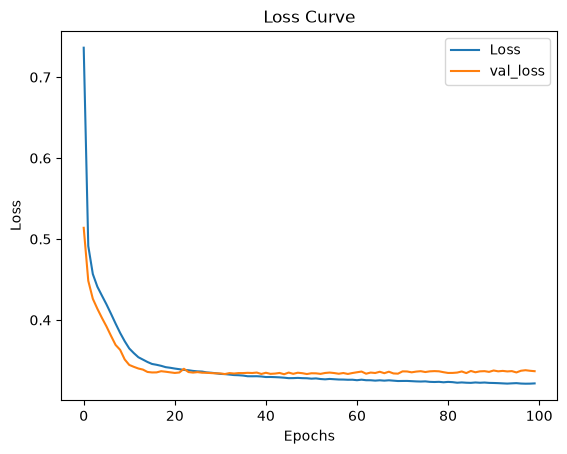

In [48]:
# =======================================
# MODULE 4: MODEL SCORE VISUALIZATION 
# =======================================

import matplotlib.pyplot as plt

# Training Loss vs  Validation Loss
plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label ='val_loss')
plt.title("Loss Curve")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

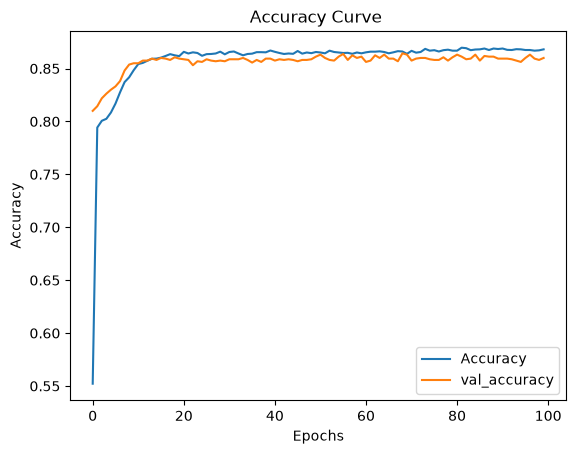

In [ ]:
# Training accuracy vs Validation accuracy
plt.plot(hist.history['accuracy'], label ="Accuracy")
plt.plot(hist.history['val_accuracy'], label = "val_accuracy")
plt.title("Accuracy Curve ")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

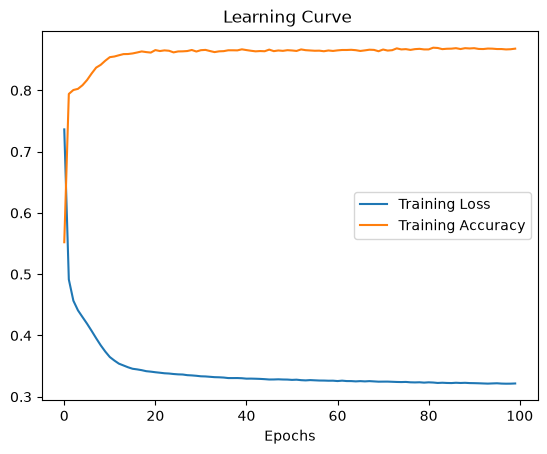

In [50]:
plt.plot(hist.history['loss'], label="Training Loss")
plt.plot(hist.history['accuracy'], label="Training Accuracy")
plt.title("Learning Curve ")
plt.xlabel('Epochs')
plt.legend()
plt.show()